In [1]:
# Import the libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, homogeneity_score
from sklearn.metrics import classification_report
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

In [3]:
# Load the datasets
## Provide a PATH where the datasets are collocated

In [4]:
def load(path):
    data = pd.read_csv(path, names=['Timestamp', 'CAN_ID', 'DLC', 'DATA[0]', 'DATA[1]', 'DATA[2]',
                                    'DATA[3]', 'DATA[4]', 'DATA[5]', 'DATA[6]', 'DATA[7]', 'Flag'], header=None)
    #data = pd.read_csv(path)

    return data

dataset = load('D:\\Automotive_Research\\Datasets\\HCRL-Car_Hacking\Dataset\\DoS_dataset.csv')
dataset1 = load('D:\\Automotive_Research\\Datasets\\HCRL-Car_Hacking\Dataset\\RPM_dataset.csv')
dataset2 = load('D:\\Automotive_Research\\Datasets\\HCRL-Car_Hacking\Dataset\\Fuzzy_dataset.csv')
dataset3 = load('D:\\Automotive_Research\\Datasets\\HCRL-Car_Hacking\Dataset\\gear_dataset.csv')
print("---- DATASET DOS ----")
print(dataset.head(10))
print("---- DATASET RPM ----")
print(dataset1.head(10))
print("---- DATASET Fuzzy ----")
print(dataset2.head(10))
print("---- DATASET Gear ----")
print(dataset3.head(10))

---- DATASET DOS ----
      Timestamp CAN_ID  DLC DATA[0] DATA[1] DATA[2] DATA[3] DATA[4] DATA[5]  \
0  1.478198e+09   0316    8      05      21      68      09      21      21   
1  1.478198e+09   018f    8      fe      5b      00      00      00      3c   
2  1.478198e+09   0260    8      19      21      22      30      08      8e   
3  1.478198e+09   02a0    8      64      00      9a      1d      97      02   
4  1.478198e+09   0329    8      40      bb      7f      14      11      20   
5  1.478198e+09   0545    8      d8      00      00      8a      00      00   
6  1.478198e+09   0002    8      00      00      00      00      00      03   
7  1.478198e+09   0153    8      00      21      10      ff      00      ff   
8  1.478198e+09   02c0    8      14      00      00      00      00      00   
9  1.478198e+09   0130    8      08      80      00      ff      31      80   

  DATA[6] DATA[7] Flag  
0      00      6f    R  
1      00      00    R  
2      6d      3a    R  
3      b

In [5]:
## Delete the first zero from the CAN ID
## Remove samples where the label is null

In [6]:
dataset["CAN_ID"] = dataset["CAN_ID"].str[1:]
dataset1["CAN_ID"] = dataset1["CAN_ID"].str[1:]
dataset2["CAN_ID"] = dataset2["CAN_ID"].str[1:]
dataset3["CAN_ID"] = dataset3["CAN_ID"].str[1:]

dataset = dataset[dataset['Flag'].isnull() == False]
dataset1 = dataset1[dataset1['Flag'].isnull() == False]
dataset2 = dataset2[dataset2['Flag'].isnull() == False]
dataset3 = dataset3[dataset3['Flag'].isnull() == False]
dataset.reset_index(drop=True, inplace=True)
dataset1.reset_index(drop=True, inplace=True)
dataset2.reset_index(drop=True, inplace=True)
dataset3.reset_index(drop=True, inplace=True)
print("---- DATASET DOS ----")
print(dataset.head(10))
print("---- DATASET RPM ----")
print(dataset1.head(10))
print("---- DATASET Fuzzy ----")
print(dataset2.head(10))
print("---- DATASET Gear ----")
print(dataset3.head(10))

---- DATASET DOS ----
      Timestamp CAN_ID  DLC DATA[0] DATA[1] DATA[2] DATA[3] DATA[4] DATA[5]  \
0  1.478198e+09    316    8      05      21      68      09      21      21   
1  1.478198e+09    18f    8      fe      5b      00      00      00      3c   
2  1.478198e+09    260    8      19      21      22      30      08      8e   
3  1.478198e+09    2a0    8      64      00      9a      1d      97      02   
4  1.478198e+09    329    8      40      bb      7f      14      11      20   
5  1.478198e+09    545    8      d8      00      00      8a      00      00   
6  1.478198e+09    002    8      00      00      00      00      00      03   
7  1.478198e+09    153    8      00      21      10      ff      00      ff   
8  1.478198e+09    2c0    8      14      00      00      00      00      00   
9  1.478198e+09    130    8      08      80      00      ff      31      80   

  DATA[6] DATA[7] Flag  
0      00      6f    R  
1      00      00    R  
2      6d      3a    R  
3      b

In [7]:
## Convert the DATA field from hex to dec

In [8]:
dataset['DATA[0]'] = dataset['DATA[0]'].apply(int, base=16)
dataset['DATA[1]'] = dataset['DATA[1]'].apply(int, base=16)
dataset['DATA[2]'] = dataset['DATA[2]'].apply(int, base=16)
dataset['DATA[3]'] = dataset['DATA[3]'].apply(int, base=16)
dataset['DATA[4]'] = dataset['DATA[4]'].apply(int, base=16)
dataset['DATA[5]'] = dataset['DATA[5]'].apply(int, base=16)
dataset['DATA[6]'] = dataset['DATA[6]'].apply(int, base=16)
dataset['DATA[7]'] = dataset['DATA[7]'].apply(int, base=16)
print("---- DATASET DOS ----")
print(dataset.head(10))

dataset1['DATA[0]'] = dataset1['DATA[0]'].apply(int, base=16)
dataset1['DATA[1]'] = dataset1['DATA[1]'].apply(int, base=16)
dataset1['DATA[2]'] = dataset1['DATA[2]'].apply(int, base=16)
dataset1['DATA[3]'] = dataset1['DATA[3]'].apply(int, base=16)
dataset1['DATA[4]'] = dataset1['DATA[4]'].apply(int, base=16)
dataset1['DATA[5]'] = dataset1['DATA[5]'].apply(int, base=16)
dataset1['DATA[6]'] = dataset1['DATA[6]'].apply(int, base=16)
dataset1['DATA[7]'] = dataset1['DATA[7]'].apply(int, base=16)
print("---- DATASET RPM ----")
print(dataset1.head(10))

dataset2['DATA[0]'] = dataset2['DATA[0]'].apply(int, base=16)
dataset2['DATA[1]'] = dataset2['DATA[1]'].apply(int, base=16)
dataset2['DATA[2]'] = dataset2['DATA[2]'].apply(int, base=16)
dataset2['DATA[3]'] = dataset2['DATA[3]'].apply(int, base=16)
dataset2['DATA[4]'] = dataset2['DATA[4]'].apply(int, base=16)
dataset2['DATA[5]'] = dataset2['DATA[5]'].apply(int, base=16)
dataset2['DATA[6]'] = dataset2['DATA[6]'].apply(int, base=16)
dataset2['DATA[7]'] = dataset2['DATA[7]'].apply(int, base=16)
print("---- DATASET Fuzzy ----")
print(dataset2.head(10))


dataset3['DATA[0]'] = dataset3['DATA[0]'].apply(int, base=16)
dataset3['DATA[1]'] = dataset3['DATA[1]'].apply(int, base=16)
dataset3['DATA[2]'] = dataset3['DATA[2]'].apply(int, base=16)
dataset3['DATA[3]'] = dataset3['DATA[3]'].apply(int, base=16)
dataset3['DATA[4]'] = dataset3['DATA[4]'].apply(int, base=16)
dataset3['DATA[5]'] = dataset3['DATA[5]'].apply(int, base=16)
dataset3['DATA[6]'] = dataset3['DATA[6]'].apply(int, base=16)
dataset3['DATA[7]'] = dataset3['DATA[7]'].apply(int, base=16)
print("---- DATASET Gear ----")
print(dataset3.head(10))

---- DATASET DOS ----
      Timestamp CAN_ID  DLC  DATA[0]  DATA[1]  DATA[2]  DATA[3]  DATA[4]  \
0  1.478198e+09    316    8        5       33      104        9       33   
1  1.478198e+09    18f    8      254       91        0        0        0   
2  1.478198e+09    260    8       25       33       34       48        8   
3  1.478198e+09    2a0    8      100        0      154       29      151   
4  1.478198e+09    329    8       64      187      127       20       17   
5  1.478198e+09    545    8      216        0        0      138        0   
6  1.478198e+09    002    8        0        0        0        0        0   
7  1.478198e+09    153    8        0       33       16      255        0   
8  1.478198e+09    2c0    8       20        0        0        0        0   
9  1.478198e+09    130    8        8      128        0      255       49   

   DATA[5]  DATA[6]  DATA[7] Flag  
0       33        0      111    R  
1       60        0        0    R  
2      142      109       58    R

In [9]:
## Perform the frequency and delta calculation

In [10]:
d = {}
a = {}

data = {}

def pre_process(row):

    if row.CAN_ID not in data:
        data[row.CAN_ID]={}
        data[row.CAN_ID]['DATA[0]'] = row['DATA[0]']
        data[row.CAN_ID]['DATA[1]'] = row['DATA[1]']
        data[row.CAN_ID]['DATA[2]'] = row['DATA[2]']
        data[row.CAN_ID]['DATA[3]'] = row['DATA[3]']
        data[row.CAN_ID]['DATA[4]'] = row['DATA[4]']
        data[row.CAN_ID]['DATA[5]'] = row['DATA[5]']
        data[row.CAN_ID]['DATA[6]'] = row['DATA[6]']
        data[row.CAN_ID]['DATA[7]'] = row['DATA[7]']
        diff = 0
        dif0 = 0
        dif1 = 0
        dif2 = 0
        dif3 = 0
        dif4 = 0
        dif5 = 0
        dif6 = 0
        dif7 = 0
    else:

        dif0 = abs(data[row.CAN_ID]['DATA[0]'] - row['DATA[0]'])
        dif1 = abs(data[row.CAN_ID]['DATA[1]'] - row['DATA[1]'])
        dif2 = abs(data[row.CAN_ID]['DATA[2]'] - row['DATA[2]'])
        dif3 = abs(data[row.CAN_ID]['DATA[3]'] - row['DATA[3]'])
        dif4 = abs(data[row.CAN_ID]['DATA[4]'] - row['DATA[4]'])
        dif5 = abs(data[row.CAN_ID]['DATA[5]'] - row['DATA[5]'])
        dif6 = abs(data[row.CAN_ID]['DATA[6]'] - row['DATA[6]'])
        dif7 = abs(data[row.CAN_ID]['DATA[7]'] - row['DATA[7]'])

        diff = dif0 + dif1 + dif2 + dif3 + dif4 + dif5 + dif6 + dif7

        data[row.CAN_ID]['DATA[0]'] = row['DATA[0]']
        data[row.CAN_ID]['DATA[1]'] = row['DATA[1]']
        data[row.CAN_ID]['DATA[2]'] = row['DATA[2]']
        data[row.CAN_ID]['DATA[3]'] = row['DATA[3]']
        data[row.CAN_ID]['DATA[4]'] = row['DATA[4]']
        data[row.CAN_ID]['DATA[5]'] = row['DATA[5]']
        data[row.CAN_ID]['DATA[6]'] = row['DATA[6]']
        data[row.CAN_ID]['DATA[7]'] = row['DATA[7]']

    if row.Flag == "R":
        if row.CAN_ID not in d:
            d[row.CAN_ID] = row.Timestamp
            freq = 0
        else:
            freq = (row.Timestamp - d[row.CAN_ID]) * 1000
            d[row.CAN_ID] = row.Timestamp
    else:
        if row.CAN_ID not in a:
            a[row.CAN_ID] = row.Timestamp
            freq = 0
        else:
            freq = (row.Timestamp - a[row.CAN_ID]) * 1000
            a[row.CAN_ID] = row.Timestamp

    bin_st = bin(int('1' + row.CAN_ID, 16))[3:]

    return freq, diff, dif0, dif1, dif2, dif3, dif4, dif5, dif6, dif7, bin_st[0], bin_st[1], bin_st[2], bin_st[3], bin_st[4], bin_st[5], bin_st[6], bin_st[7], bin_st[8], \
           bin_st[9], bin_st[10], bin_st[11]

In [11]:
## Preprocessing dataset DoS

In [12]:
d = {}
a = {}
data = {}
dataset[['FREQUENCY', 'DELTA_TOT', 'DELTA_DATA[0]', 'DELTA_DATA[1]', 'DELTA_DATA[2]', 'DELTA_DATA[3]', 'DELTA_DATA[4]',
         'DELTA_DATA[5]', 'DELTA_DATA[6]', 'DELTA_DATA[7]', 'CAN_ID_0', 'CAN_ID_1', 'CAN_ID_2', 'CAN_ID_3', 'CAN_ID_4',
         'CAN_ID_5', 'CAN_ID_6', 'CAN_ID_7', 'CAN_ID_8', 'CAN_ID_9', 'CAN_ID_10', 'CAN_ID_11']] = dataset.apply(
    pre_process, axis=1, result_type="expand")
dataset.reset_index(drop=True, inplace=True)
dataset = dataset[['Timestamp', 'FREQUENCY', 'DELTA_TOT', 'DELTA_DATA[0]', 'DELTA_DATA[1]', 'DELTA_DATA[2]',
                   'DELTA_DATA[3]', 'DELTA_DATA[4]', 'DELTA_DATA[5]', 'DELTA_DATA[6]', 'DELTA_DATA[7]', 'CAN_ID',
                   'CAN_ID_0', 'CAN_ID_1', 'CAN_ID_2', 'CAN_ID_3', 'CAN_ID_4', 'CAN_ID_5', 'CAN_ID_6', 'CAN_ID_7',
                   'CAN_ID_8', 'CAN_ID_9', 'CAN_ID_10', 'CAN_ID_11', 'DLC', 'DATA[0]', 'DATA[1]', 'DATA[2]', 'DATA[3]',
                   'DATA[4]', 'DATA[5]', 'DATA[6]', 'DATA[7]', 'Flag']]
print(dataset.head(10))
dataset.to_csv("dos_new.csv", index=False)

      Timestamp  FREQUENCY  DELTA_TOT  DELTA_DATA[0]  DELTA_DATA[1]  \
0  1.478198e+09        0.0          0              0              0   
1  1.478198e+09        0.0          0              0              0   
2  1.478198e+09        0.0          0              0              0   
3  1.478198e+09        0.0          0              0              0   
4  1.478198e+09        0.0          0              0              0   
5  1.478198e+09        0.0          0              0              0   
6  1.478198e+09        0.0          0              0              0   
7  1.478198e+09        0.0          0              0              0   
8  1.478198e+09        0.0          0              0              0   
9  1.478198e+09        0.0          0              0              0   

   DELTA_DATA[2]  DELTA_DATA[3]  DELTA_DATA[4]  DELTA_DATA[5]  DELTA_DATA[6]  \
0              0              0              0              0              0   
1              0              0              0            

In [13]:
## Preprocessing dataset RPM

In [14]:
d = {}
a = {}
data = {}
dataset1[['FREQUENCY', 'DELTA_TOT', 'DELTA_DATA[0]', 'DELTA_DATA[1]', 'DELTA_DATA[2]', 'DELTA_DATA[3]', 'DELTA_DATA[4]',
         'DELTA_DATA[5]', 'DELTA_DATA[6]', 'DELTA_DATA[7]', 'CAN_ID_0', 'CAN_ID_1', 'CAN_ID_2', 'CAN_ID_3', 'CAN_ID_4',
         'CAN_ID_5', 'CAN_ID_6', 'CAN_ID_7', 'CAN_ID_8', 'CAN_ID_9', 'CAN_ID_10', 'CAN_ID_11']] = dataset1.apply(
    pre_process, axis=1, result_type="expand")
dataset1.reset_index(drop=True, inplace=True)
dataset1 = dataset1[['Timestamp', 'FREQUENCY', 'DELTA_TOT', 'DELTA_DATA[0]', 'DELTA_DATA[1]', 'DELTA_DATA[2]',
                   'DELTA_DATA[3]', 'DELTA_DATA[4]', 'DELTA_DATA[5]', 'DELTA_DATA[6]', 'DELTA_DATA[7]', 'CAN_ID',
                   'CAN_ID_0', 'CAN_ID_1', 'CAN_ID_2', 'CAN_ID_3', 'CAN_ID_4', 'CAN_ID_5', 'CAN_ID_6', 'CAN_ID_7',
                   'CAN_ID_8', 'CAN_ID_9', 'CAN_ID_10', 'CAN_ID_11', 'DLC', 'DATA[0]', 'DATA[1]', 'DATA[2]', 'DATA[3]',
                   'DATA[4]', 'DATA[5]', 'DATA[6]', 'DATA[7]', 'Flag']]
print(dataset1.head(10))
dataset1.to_csv("rpm_new.csv", index=False)

      Timestamp  FREQUENCY  DELTA_TOT  DELTA_DATA[0]  DELTA_DATA[1]  \
0  1.478191e+09        0.0          0              0              0   
1  1.478191e+09        0.0          0              0              0   
2  1.478191e+09        0.0          0              0              0   
3  1.478191e+09        0.0          0              0              0   
4  1.478191e+09        0.0          0              0              0   
5  1.478191e+09        0.0          0              0              0   
6  1.478191e+09        0.0          0              0              0   
7  1.478191e+09        0.0          0              0              0   
8  1.478191e+09        0.0          0              0              0   
9  1.478191e+09        0.0          0              0              0   

   DELTA_DATA[2]  DELTA_DATA[3]  DELTA_DATA[4]  DELTA_DATA[5]  DELTA_DATA[6]  \
0              0              0              0              0              0   
1              0              0              0            

In [15]:
## Preprocessing dataset Fuzzy

In [16]:
d = {}
a = {}
data = {}
dataset2[['FREQUENCY', 'DELTA_TOT', 'DELTA_DATA[0]', 'DELTA_DATA[1]', 'DELTA_DATA[2]', 'DELTA_DATA[3]', 'DELTA_DATA[4]',
         'DELTA_DATA[5]', 'DELTA_DATA[6]', 'DELTA_DATA[7]', 'CAN_ID_0', 'CAN_ID_1', 'CAN_ID_2', 'CAN_ID_3', 'CAN_ID_4',
         'CAN_ID_5', 'CAN_ID_6', 'CAN_ID_7', 'CAN_ID_8', 'CAN_ID_9', 'CAN_ID_10', 'CAN_ID_11']] = dataset2.apply(
    pre_process, axis=1, result_type="expand")
dataset2.reset_index(drop=True, inplace=True)
dataset2 = dataset2[['Timestamp', 'FREQUENCY', 'DELTA_TOT', 'DELTA_DATA[0]', 'DELTA_DATA[1]', 'DELTA_DATA[2]',
                   'DELTA_DATA[3]', 'DELTA_DATA[4]', 'DELTA_DATA[5]', 'DELTA_DATA[6]', 'DELTA_DATA[7]', 'CAN_ID',
                   'CAN_ID_0', 'CAN_ID_1', 'CAN_ID_2', 'CAN_ID_3', 'CAN_ID_4', 'CAN_ID_5', 'CAN_ID_6', 'CAN_ID_7',
                   'CAN_ID_8', 'CAN_ID_9', 'CAN_ID_10', 'CAN_ID_11', 'DLC', 'DATA[0]', 'DATA[1]', 'DATA[2]', 'DATA[3]',
                   'DATA[4]', 'DATA[5]', 'DATA[6]', 'DATA[7]', 'Flag']]
print(dataset2.head(10))
dataset2.to_csv("fuzzy_new.csv", index=False)

      Timestamp  FREQUENCY  DELTA_TOT  DELTA_DATA[0]  DELTA_DATA[1]  \
0  1.478196e+09        0.0          0              0              0   
1  1.478196e+09        0.0          0              0              0   
2  1.478196e+09        0.0          0              0              0   
3  1.478196e+09        0.0          0              0              0   
4  1.478196e+09        0.0          0              0              0   
5  1.478196e+09        0.0          0              0              0   
6  1.478196e+09        0.0          0              0              0   
7  1.478196e+09        0.0          0              0              0   
8  1.478196e+09        0.0          0              0              0   
9  1.478196e+09        0.0          0              0              0   

   DELTA_DATA[2]  DELTA_DATA[3]  DELTA_DATA[4]  DELTA_DATA[5]  DELTA_DATA[6]  \
0              0              0              0              0              0   
1              0              0              0            

In [17]:
## Preprocessing dataset Gear

In [18]:
d = {}
a = {}
data = {}
dataset3[['FREQUENCY', 'DELTA_TOT', 'DELTA_DATA[0]', 'DELTA_DATA[1]', 'DELTA_DATA[2]', 'DELTA_DATA[3]', 'DELTA_DATA[4]',
         'DELTA_DATA[5]', 'DELTA_DATA[6]', 'DELTA_DATA[7]', 'CAN_ID_0', 'CAN_ID_1', 'CAN_ID_2', 'CAN_ID_3', 'CAN_ID_4',
         'CAN_ID_5', 'CAN_ID_6', 'CAN_ID_7', 'CAN_ID_8', 'CAN_ID_9', 'CAN_ID_10', 'CAN_ID_11']] = dataset3.apply(
    pre_process, axis=1, result_type="expand")
dataset3.reset_index(drop=True, inplace=True)
dataset3 = dataset3[['Timestamp', 'FREQUENCY', 'DELTA_TOT', 'DELTA_DATA[0]', 'DELTA_DATA[1]', 'DELTA_DATA[2]',
                   'DELTA_DATA[3]', 'DELTA_DATA[4]', 'DELTA_DATA[5]', 'DELTA_DATA[6]', 'DELTA_DATA[7]', 'CAN_ID',
                   'CAN_ID_0', 'CAN_ID_1', 'CAN_ID_2', 'CAN_ID_3', 'CAN_ID_4', 'CAN_ID_5', 'CAN_ID_6', 'CAN_ID_7',
                   'CAN_ID_8', 'CAN_ID_9', 'CAN_ID_10', 'CAN_ID_11', 'DLC', 'DATA[0]', 'DATA[1]', 'DATA[2]', 'DATA[3]',
                   'DATA[4]', 'DATA[5]', 'DATA[6]', 'DATA[7]', 'Flag']]
print(dataset3.head(10))
dataset3.to_csv("gear_new.csv", index=False)

      Timestamp  FREQUENCY  DELTA_TOT  DELTA_DATA[0]  DELTA_DATA[1]  \
0  1.478193e+09        0.0          0              0              0   
1  1.478193e+09        0.0          0              0              0   
2  1.478193e+09        0.0          0              0              0   
3  1.478193e+09        0.0          0              0              0   
4  1.478193e+09        0.0          0              0              0   
5  1.478193e+09        0.0          0              0              0   
6  1.478193e+09        0.0          0              0              0   
7  1.478193e+09        0.0          0              0              0   
8  1.478193e+09        0.0          0              0              0   
9  1.478193e+09        0.0          0              0              0   

   DELTA_DATA[2]  DELTA_DATA[3]  DELTA_DATA[4]  DELTA_DATA[5]  DELTA_DATA[6]  \
0              0              0              0              0              0   
1              0              0              0            

In [19]:
## Map the label
## 0 = Normal, 1 = DoS, 2 = RPM, 3 = Fuzzy, 4 = Gear

In [20]:
dataset['Flag'] = dataset['Flag'].map({'R': 0, 'T': 1})
dataset1['Flag'] = dataset1['Flag'].map({'R': 0, 'T': 2})
dataset2['Flag'] = dataset2['Flag'].map({'R': 0, 'T': 3})
dataset3['Flag'] = dataset3['Flag'].map({'R': 0, 'T': 4})

In [21]:
## Reduce the dimensionality on the Normal samples

In [22]:
index = dataset.index[dataset['Flag'] == 0].tolist()
index = index[0:1900000]
dataset.drop(dataset.index[index], inplace=True)
dataset.reset_index(drop=True, inplace=True)

index = dataset1.index[dataset1['Flag'] == 0].tolist()
index = index[0:1900000]
dataset1.drop(dataset1.index[index], inplace=True)
dataset1.reset_index(drop=True, inplace=True)


index = dataset2.index[dataset2['Flag'] == 0].tolist()
index = index[0:1900000]
dataset2.drop(dataset2.index[index], inplace=True)
dataset2.reset_index(drop=True, inplace=True)


index = dataset3.index[dataset3['Flag'] == 0].tolist()
index = index[0:1900000]
dataset3.drop(dataset3.index[index], inplace=True)
dataset3.reset_index(drop=True, inplace=True)

In [23]:
## Concat the datasets

In [24]:
dataset = pd.concat([dataset, dataset1, dataset2, dataset3], axis=0)
dataset.reset_index(drop=True, inplace=True)

In [25]:
## Drop the features

In [26]:
dataset = dataset.drop('Timestamp', axis=1)
dataset = dataset.drop('CAN_ID', axis=1)
dataset = dataset.drop('DLC', axis=1)

In [ ]:
# K-means evaluation on the elbow and homogeneity

In [ ]:
def kmeansEvaluate(X_scaled, minK, maxK, seed):
    inertias = []
    for i in range(minK, maxK):
        kmeans = KMeans(n_clusters=i, init='random', max_iter=300, n_init=10, random_state=seed)
        kmeans.fit(X_scaled)
        print(i)
        inertias.append(kmeans.inertia_)

    print("Elbow method:")
    plt.plot(range(minK, maxK), inertias)
    plt.title('Elbow Method')
    plt.xlabel('Number of clusters')
    plt.ylabel('Inertia')
    plt.xticks(np.arange(minK, maxK + 1, 1.0))
    plt.show()


def kmeansEvaluateHomo(X_scaled, XTest_scaled, YTest, minK, maxK, seed):
    scores = []
    best_homo = 0
    best_k = 0
    for i in range(minK, maxK):
        kmeans = KMeans(n_clusters=i, init='random', max_iter=300, n_init=10, random_state=seed)
        kmeans.fit(X_scaled)
        predictedClusters = kmeans.predict(XTest_scaled)  # QUI STAVA XTest-scaled
        score = metrics.homogeneity_completeness_v_measure(YTest, predictedClusters)
        scores.append(score)
        print(i)
        if score[0] > best_homo:
            best_homo = score[0]
            best_k = i

    print("homogeneity eval:")
    plt.title('Homogeneity evaluation:')
    plt.plot(range(minK, maxK), [s[0] for s in scores], 'r', label='Homogeneity')
    plt.xlabel('Value of K')
    plt.ylabel('Homogeneity')
    plt.xticks(np.arange(minK, maxK + 1, 1.0))
    #plt.legend(loc=4)
    plt.show()

    return best_k

In [27]:
# Class to cluster function

In [28]:
def classToCluster(y, kmeans_labels, class_names):
    clusters = set(kmeans_labels)
    classes = set(y)
    classToCluster = []
    n_clust_example = 0
    N = 0
    pur = 0

    for c in clusters:
        clust_examples = []
        indices = np.where(kmeans_labels == c)[0]
        print(len(indices))
        for i in indices:
            clust_examples.append(y[i])
        maxClass = -1
        max_n_clust_example = -1

        print("\nCluster: ", c)
        for cl in classes:
            n_clust_example = clust_examples.count(cl)
            N += n_clust_example
            print(class_names[cl], ":", n_clust_example, "examples")
            if n_clust_example > max_n_clust_example:
                maxClass = cl
                max_n_clust_example = n_clust_example
        pur += max_n_clust_example
        classToCluster.append(maxClass)
    pur = pur / N

    return clusters, classToCluster, pur

In [29]:
## Create the train and test split

In [30]:
seed = 43
np.random.seed(seed)

class_names = ["Normal", "Dos", "RPM Spoofing", "Fuzzy", "Gear Spoofing"]
target = 'Flag'
cols = list(dataset.columns.values)
independentList = cols[0:dataset.shape[1] - 1]

X = dataset.loc[:, independentList]
y = dataset[target]

X, XTest, y, YTest = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)


X.reset_index(drop=True, inplace=True)
XTest.reset_index(drop=True, inplace=True)

y.reset_index(drop=True, inplace=True)
YTest.reset_index(drop=True, inplace=True)

581851

Cluster:  0
Normal : 580357 examples
Dos : 0 examples
RPM Spoofing : 0 examples
Fuzzy : 1494 examples
Gear Spoofing : 0 examples
528978

Cluster:  1
Normal : 527311 examples
Dos : 0 examples
RPM Spoofing : 0 examples
Fuzzy : 1667 examples
Gear Spoofing : 0 examples
267152

Cluster:  2
Normal : 266079 examples
Dos : 0 examples
RPM Spoofing : 0 examples
Fuzzy : 1073 examples
Gear Spoofing : 0 examples
440865

Cluster:  3
Normal : 0 examples
Dos : 440641 examples
RPM Spoofing : 0 examples
Fuzzy : 224 examples
Gear Spoofing : 0 examples
522617

Cluster:  4
Normal : 520922 examples
Dos : 0 examples
RPM Spoofing : 0 examples
Fuzzy : 1695 examples
Gear Spoofing : 0 examples
261406

Cluster:  5
Normal : 261027 examples
Dos : 0 examples
RPM Spoofing : 0 examples
Fuzzy : 379 examples
Gear Spoofing : 0 examples
527691

Cluster:  6
Normal : 523759 examples
Dos : 0 examples
RPM Spoofing : 0 examples
Fuzzy : 3932 examples
Gear Spoofing : 0 examples
265173

Cluster:  7
Normal : 264702 example

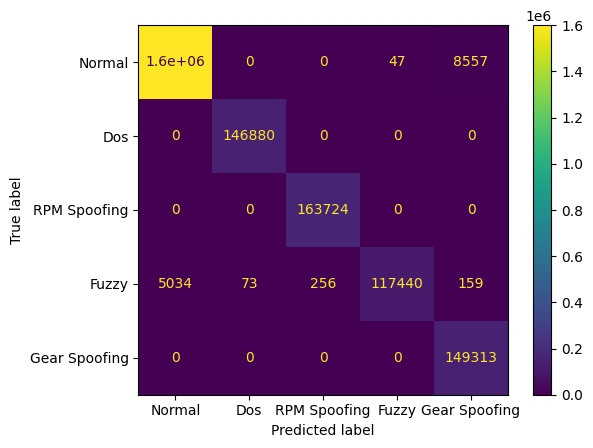


Classification report:
{'Normal': {'precision': 0.9968650241568758, 'recall': 0.9946536558207049, 'f1-score': 0.9957581122448663, 'support': 1609324}, 'Dos': {'precision': 0.999503242533327, 'recall': 1.0, 'f1-score': 0.9997515595593416, 'support': 146880}, 'RPM Spoofing': {'precision': 0.9984388340041469, 'recall': 1.0, 'f1-score': 0.9992188072162684, 'support': 163724}, 'Fuzzy': {'precision': 0.999599955739784, 'recall': 0.9550918169841089, 'f1-score': 0.9768391633984754, 'support': 122962}, 'Gear Spoofing': {'precision': 0.9448455663201059, 'recall': 1.0, 'f1-score': 0.9716407129516955, 'support': 149313}, 'accuracy': 0.9935562536863602, 'macro avg': {'precision': 0.9878505245508478, 'recall': 0.9899490945609628, 'f1-score': 0.9886416710741296, 'support': 2192203}, 'weighted avg': {'precision': 0.9937696371456746, 'recall': 0.9935562536863602, 'f1-score': 0.993580304503675, 'support': 2192203}}


In [31]:
# Scaling X and XTest
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

XTest_scaled = scaler.transform(XTest)

# Elbow method
# minK = 6
# maxK = 25

k = 15
kmeans = KMeans(n_clusters=k, init='random', max_iter=300, n_init=10, random_state=seed)
kmeans.fit(X_scaled)

cluster, classtoCluster, pur = classToCluster(y, kmeans.labels_, class_names)
cluster_class = dict(zip(cluster, classtoCluster))


print("\nResults:\n")
print("Cluster:Class =", cluster_class)
print("\n# of cluster assigned to each class:")
print("Class 0: ", sum(1 for v in cluster_class.values() if v == 0),
    np.where(np.array(list(cluster_class.values())) == 0)[0])
print("Class 1: ", sum(1 for v in cluster_class.values() if v == 1),
    np.where(np.array(list(cluster_class.values())) == 1)[0])
print("Class 2: ", sum(1 for v in cluster_class.values() if v == 2),
    np.where(np.array(list(cluster_class.values())) == 2)[0])
print("Class 3: ", sum(1 for v in cluster_class.values() if v == 3),
    np.where(np.array(list(cluster_class.values())) == 3)[0])
print("Class 4: ", sum(1 for v in cluster_class.values() if v == 4),
    np.where(np.array(list(cluster_class.values())) == 4)[0])

print('\nPurity= ', pur)

predictedClusters = kmeans.predict(XTest_scaled)
Y_Pred = [cluster_class.get(key) for key in predictedClusters]

# Confusion matrix and classification report

cm = confusion_matrix(YTest, Y_Pred)
print("Confusion matrix:")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot()
plt.show()

print("\nClassification report:")
print(classification_report(YTest, Y_Pred, target_names=class_names, output_dict=True))